# Demo of Score Based Diffusion model

Here we will see how to implement a simple diffusion model from scratch for MNIST

## Setup and data

We start with the necessary imports and make sure you are connected to a T4 Iinstant provided by colab!

In [ ]:
import os
import random
import numpy as np
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torchvision.utils import make_grid


# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Then we get the data and some data processing.

In [8]:
# Hyperparams you can adjust
batch_size = 128
root = "./data"

# MNIST transform - convert to tensor and scale to [-1,1] which is convenient for many diffusion examples
transform = transforms.Compose([
    transforms.ToTensor(),                     # -> [0,1]
    transforms.Lambda(lambda t: (t - 0.5) * 2) # -> [-1,1]
])

train_ds = datasets.MNIST(root=root, train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root=root, train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

print("Train size:", len(train_ds), "Test size:", len(test_ds))

Train size: 60000 Test size: 10000


Now we show a small grid of images (rescale from [-1,1] back to [0,1] for plotting)


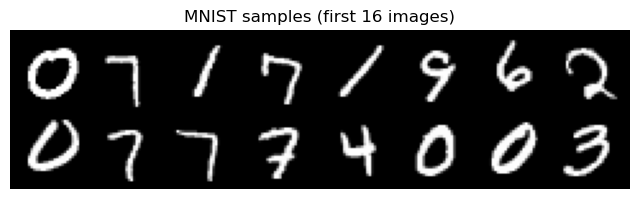

Labels: [0 7 1 7 1 9 6 2 0 7 7 7 4 0 0 3]


In [9]:
batch = next(iter(train_loader))
x, y = batch
# x shape: [B,1,28,28], values in [-1,1]
grid = utils.make_grid(x[:16], nrow=8, normalize=True, scale_each=True)  # normalize maps to [0,1] for display
plt.figure(figsize=(8,4))
plt.imshow(grid.permute(1,2,0).cpu().numpy(), cmap='gray')
plt.axis('off')
plt.title("MNIST samples (first 16 images)")
plt.show()

print("Labels:", y[:16].cpu().numpy())

## Unconditional Diffusion Model

Here we first define the diffusion process in the class called VESDE

### Defining the SDE

In [10]:
class VESDE: #class used
  def __init__(self, sigma_min=0.01, sigma_max=50, N=1000): #sigma is a noise thing, sigma<simga2<...<sigmaT
    """Construct a Variance Exploding SDE.

    Args:
      sigma_min: smallest sigma.
      sigma_max: largest sigma.
      N: number of discretization steps
    """
    super().__init__()
    self.sigma_min = sigma_min
    self.sigma_max = sigma_max
    self.N = N
    self.probability_flow = False

  @property
  def T(self):
    return 1

  def sde(self, x, t):
    sigma = self.sigma_min * (self.sigma_max / self.sigma_min) ** t
    drift = torch.zeros_like(x) #is the f in the formula (dx=fdt+gdW)
    diffusion = sigma * torch.sqrt(torch.tensor(2 * (np.log(self.sigma_max) - np.log(self.sigma_min)),
                                                device=t.device))
    return drift, diffusion

  def forward(self, x, t):
    std = self.sigma_min * (self.sigma_max / self.sigma_min) ** t
    mean = x
    return mean, std

  def prior_sampling(self, shape):
    return torch.randn(*shape) * self.sigma_max


  def reverse_sde(self, x, t, score_fn, probability_flow = False, labels = None):
    """Create the drift and diffusion functions for the reverse SDE/ODE."""
    drift, diffusion = self.sde(x, t)
    if labels == None:
      score = score_fn(x, t)
    else:
      score = score_fn(x, t, labels)
    drift = drift - diffusion[:, None, None, None] ** 2 * score * (0.5 if probability_flow else 1.)

    diffusion = 0. if probability_flow else diffusion # Set the diffusion function to zero for ODEs. (not relevant for the lecture as we don't cover probability flow ODEs)
    return drift, diffusion

### Exercise on forward noising

In the next section I want you to add noise to a small batch of images.
Choose:


```
sigma_min=0.01, sigma_max=50, N=1000
```
and for times


```
times = 0.0, 0.25, 0.5, 0.75, 1.0
```





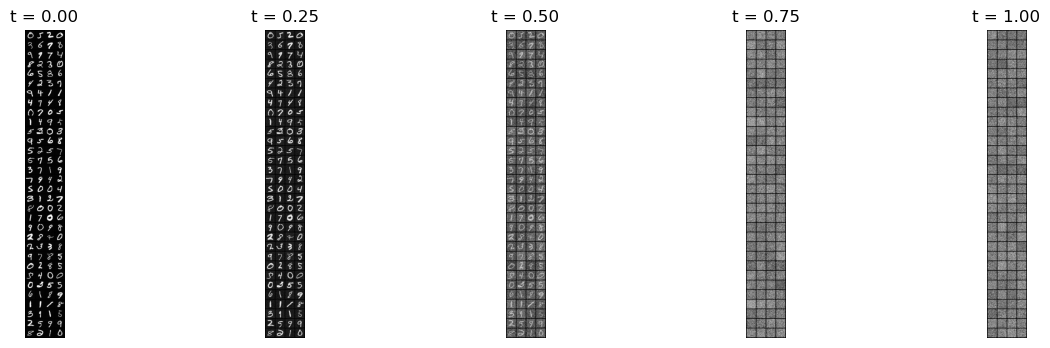

In [16]:
# NOT COMPLETE

# Create VE SDE object
sde = VESDE(sigma_min=0.01, sigma_max=50, N=1000)

# Get one batch from MNIST loader
x0, _ = next(iter(train_loader))
x0 = x0.to(device)

# Select several time values
times = torch.tensor([0.0, 0.25, 0.5, 0.75, 1.0], device=device)

noisy_images = []

for t in times:
  t_batch = torch.ones(x0.shape[0], device=device) * t
  mean, std = sde.forward(x0, t_batch)
  z = torch.randn_like(x0)
  x_t = mean + std[:, None, None, None] * z
  noisy_images.append(x_t.detach().cpu())
  # break

# Plot results
fig, axes = plt.subplots(1, len(times), figsize=(15, 4))

for i, (ax, t) in enumerate(zip(axes, times)):
    grid = make_grid(noisy_images[i], nrow=4, normalize=True, scale_each=True)
    ax.imshow(grid.permute(1,2,0))
    ax.set_title(f"t = {float(t):.2f}")
    ax.axis("off")

plt.show()

##### Solution

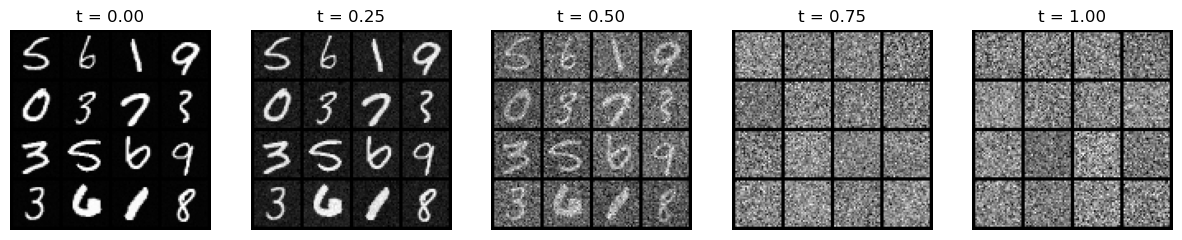

In [17]:
#solution for above
# Create VE SDE object
sde = VESDE(sigma_min=0.01, sigma_max=50, N=1000)

# Get one batch from MNIST loader
x0, _ = next(iter(train_loader))
x0 = x0.to(device)

# Select several time values
times = torch.tensor([0.0, 0.25, 0.5, 0.75, 1.0], device=device)

noisy_images = []

for t in times:
    # t must have shape [B]
    t_batch = torch.ones(x0.shape[0], device=device) * t

    # Forward marginal distribution: x_t = x0 + sigma(t)*z
    mean, std = sde.forward(x0, t_batch)

    z = torch.randn_like(x0)
    x_t = mean + std[:, None, None, None] * z

    # store only first 16 images for display
    noisy_images.append(x_t[:16].detach().cpu())

# Plot results
fig, axes = plt.subplots(1, len(times), figsize=(15, 4))

for i, (ax, t) in enumerate(zip(axes, times)):
    grid = make_grid(noisy_images[i], nrow=4, normalize=True, scale_each=True)
    ax.imshow(grid.permute(1,2,0))
    ax.set_title(f"t = {float(t):.2f}")
    ax.axis("off")

plt.show()


### Creating the Score Network

This score network is a UNET containing time embedding. Note that it is AI generated. :)

In [18]:
# --------------------------
# Helpers: Time embeddings
# --------------------------

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        """
        t: shape [B]
        returns [B, dim]
        """
        half = self.dim // 2
        emb = torch.exp(
            torch.arange(half, device=t.device) * -torch.log(torch.tensor(10000.0)) / (half - 1)
        )
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb


# --------------------------
# Residual Block
# --------------------------

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(4, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.time_mlp = nn.Linear(time_dim, out_ch)

        self.norm2 = nn.GroupNorm(4, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        if in_ch != out_ch:
            self.shortcut = nn.Conv2d(in_ch, out_ch, 1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.shortcut(x)


# --------------------------
# Full UNet
# --------------------------

class UNet(nn.Module):
    def __init__(self, base_ch=64, time_dim=128):
        super().__init__()

        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # Down
        self.conv_in = nn.Conv2d(1, base_ch, 3, padding=1)
        self.down1 = ResBlock(base_ch, base_ch*2, time_dim)
        self.down2 = ResBlock(base_ch*2, base_ch*4, time_dim)
        self.pool = nn.AvgPool2d(2)

        # Bottleneck
        self.mid1 = ResBlock(base_ch*4, base_ch*4, time_dim)
        self.mid2 = ResBlock(base_ch*4, base_ch*4, time_dim)

        # Up
        self.up1 = ResBlock(base_ch*4 + base_ch*4, base_ch*2, time_dim)
        self.up2 = ResBlock(base_ch*2 + base_ch*2, base_ch, time_dim)

        self.conv_out = nn.Conv2d(base_ch, 1, 3, padding=1)

    def forward(self, x, t):
        # time embedding
        t_emb = self.time_embed(t)

        # down path
        h1 = self.conv_in(x)
        h2 = self.down1(h1, t_emb)
        h3 = self.pool(h2)
        h4 = self.down2(h3, t_emb)
        h5 = self.pool(h4)

        # bottleneck
        h_mid = self.mid1(h5, t_emb)
        h_mid = self.mid2(h_mid, t_emb)

        # up path
        h = F.interpolate(h_mid, scale_factor=2, mode='nearest')
        h = self.up1(torch.cat([h, h4], dim=1), t_emb)

        h = F.interpolate(h, scale_factor=2, mode='nearest')
        h = self.up2(torch.cat([h, h2], dim=1), t_emb)

        return self.conv_out(F.silu(h))


## Build training loop

In [19]:
# helepr function which takes in noised image and time to get the neural network output
def get_score_fn(sde, model):
    def score_fn(x, t):
        labels = t * 999 # [0, 1] -> [0, 999]
        score = model(x, labels)
        std = sde.forward(torch.zeros_like(x), t)[1]
        score = -score / std[:, None, None, None]
        return score
    return score_fn

The training step for one batch. Note how the loss function matches what we derived

In [20]:
def train_step(config, batch, model, sde, optim, train = True):
    if train == True:
        model.train()
    else:
        model.eval()

    score_fn = get_score_fn(sde, model)

    t = torch.rand(batch.shape[0], device=batch.device) * (sde.T - config.eps) + config.eps
    z = torch.randn_like(batch)
    mean, std = sde.forward(batch, t)
    perturbed_data = mean + std[:, None, None, None] * z
    score = score_fn(perturbed_data, t)

    losses = torch.square(score * std[:, None, None, None] + z)

    losses = torch.mean(losses.reshape(losses.shape[0], -1), dim=-1)
    loss = torch.mean(losses)

    if train == True:
        optim.zero_grad()
        loss.backward()
        optim.step()

    return loss

Epoch 1/6:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: loss = 0.161929


Epoch 2/6:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: loss = 0.078236


Epoch 3/6:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 4: loss = 0.067449


Epoch 5/6:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 5: loss = 0.064902


Epoch 6/6:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 6: loss = 0.063899


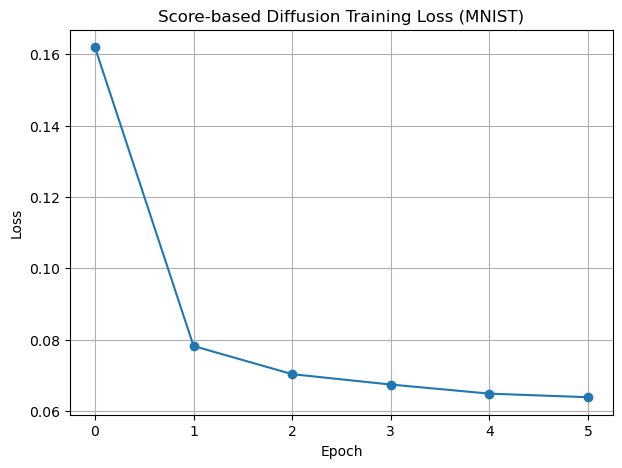

In [21]:
# ======================
# CONFIG
# ======================
class Config:
    lr = 2e-4
    epochs = 6
    eps = 1e-5
    device = device

config = Config()

sde = VESDE(sigma_min=0.01, sigma_max=50, N=1000)

model = UNet().to(config.device)
optimizer = optim.Adam(model.parameters(), lr=config.lr)

# ======================
# TRAINING LOOP
# ======================
train_losses = []

for epoch in range(config.epochs):
    epoch_losses = []
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.epochs}")

    for batch, _ in pbar:
        batch = batch.to(config.device)

        loss = train_step(config, batch, model, sde, optimizer, train=True)
        epoch_losses.append(loss.item())

        pbar.set_postfix(loss=loss.item())

    mean_epoch_loss = sum(epoch_losses) / len(epoch_losses)
    train_losses.append(mean_epoch_loss)

    print(f"Epoch {epoch+1}: loss = {mean_epoch_loss:.6f}")

# ======================
# PLOT TRAINING CURVE
# ======================
plt.figure(figsize=(7,5))
plt.plot(train_losses, marker='o')
plt.title("Score-based Diffusion Training Loss (MNIST)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## Sampler

Now that we have trained the model, let's build the sampler

In [22]:
class Sampler:
  def __init__(self, sde, score_fn):
    super().__init__()
    self.sde = sde
    self.score_fn = score_fn

  def update_fn(self, x, t):
    dt = -1. / self.sde.N
    z = torch.randn_like(x)
    drift, diffusion = self.sde.reverse_sde(x, t, self.score_fn)
    x_mean = x + drift * dt
    x = x_mean + diffusion[:, None, None, None] * np.sqrt(-dt) * z
    return x, x_mean


def sample(sde, model, num_samples = 1000, eps=1e-5, device = torch.device("cuda" if torch.cuda.is_available() else "cpu")):
    model.eval()
    score_fn = get_score_fn(sde, model)
    sampler = Sampler(sde = sde, score_fn = score_fn)
    shape = [num_samples, 1, 28, 28] # the shape has been hardcoded!
    x = sde.prior_sampling(shape).to(device)
    timesteps = torch.linspace(sde.T, eps, sde.N, device=device)
    with torch.no_grad():
      for i in tqdm(range(sde.N)):
          t = torch.ones(shape[0], device=device) * timesteps[i]
          x, x_mean = sampler.update_fn(x, t)

    return x_mean

And now we generate samples!

In [23]:
samples = sample(sde, model, eps = config.eps, num_samples = 20)

  0%|          | 0/1000 [00:00<?, ?it/s]

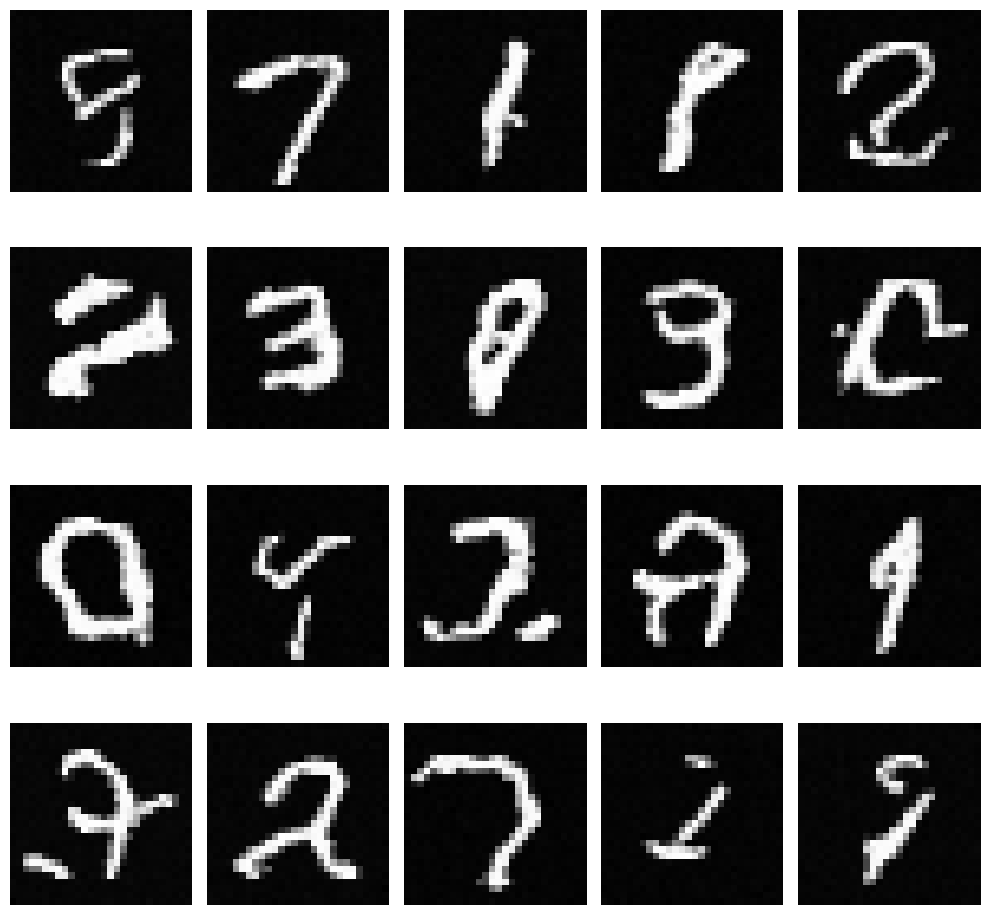

In [24]:
samples = samples.detach().cpu()   # ensure on CPU, no grad

fig, axes = plt.subplots(4, 5, figsize=(10, 10))

for i, ax in enumerate(axes.flatten()):
    img = samples[i, 0]            # [28, 28]
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conditional Diffusion exercise

Here try building a conditional model for MNIST.

*   The labels must enter the score network as one hot encoding and so you need a new score network which you can call `UNetConditional`. This has been provided below with a small example showing how it works.
*   You need to modify the following: `get_score_fn`, `train_step`, the training loop, and the `Sampler` class.
*   You should train it for at least 10 iterations.






### The `UNetConditional` is provided below

In [25]:
# --- Time embedding ---
def sinusoidal_embedding(timesteps, dim=256):
    half = dim // 2
    freqs = torch.exp(
        torch.linspace(
            0,
            torch.log(torch.tensor(10000.0)),
            half, device=timesteps.device
        )
    )
    args = timesteps[:, None] * freqs[None, :]
    embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    return embedding

# --- Residual block ---
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, cond_dim):
        super().__init__()
        # FIX: GroupNorm(1, channels) always works
        self.norm1 = nn.GroupNorm(1, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm2 = nn.GroupNorm(1, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.cond_proj = nn.Linear(cond_dim, out_ch)

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, cond):
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        h = self.norm2(h)
        h = F.silu(h)

        cond_h = self.cond_proj(cond)[..., None, None]
        h = h + cond_h

        h = self.conv2(h)
        return h + self.skip(x)


# --- Conditional UNet ---
class UNetConditional(nn.Module):
    def __init__(self, num_classes=10, base_ch=64):
        super().__init__()

        self.time_dim = 256
        self.label_dim = 128
        self.cond_dim = self.time_dim + self.label_dim

        # Embeddings
        self.label_emb = nn.Linear(num_classes, self.label_dim)
        self.time_emb = nn.Linear(self.time_dim, self.time_dim)

        # Encoder
        self.enc1 = ResBlock(1, base_ch, self.cond_dim)
        self.down1 = nn.Conv2d(base_ch, base_ch, 4, stride=2, padding=1)

        self.enc2 = ResBlock(base_ch, base_ch * 2, self.cond_dim)
        self.down2 = nn.Conv2d(base_ch * 2, base_ch * 2, 4, stride=2, padding=1)

        self.enc3 = ResBlock(base_ch * 2, base_ch * 4, self.cond_dim)

        # Decoder
        self.up1 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 4, stride=2, padding=1)
        self.dec1 = ResBlock(base_ch * 4, base_ch * 2, self.cond_dim)

        self.up2 = nn.ConvTranspose2d(base_ch * 2, base_ch, 4, stride=2, padding=1)
        self.dec2 = ResBlock(base_ch * 2, base_ch, self.cond_dim)

        # Output
        self.out = nn.Conv2d(base_ch, 1, 3, padding=1)

    def forward(self, x, t, y):
        # --- Conditioning ---
        t_emb = sinusoidal_embedding(t, self.time_dim)
        t_emb = self.time_emb(t_emb)

        y_onehot = F.one_hot(y, num_classes=10).float()
        y_emb = self.label_emb(y_onehot)

        cond = torch.cat([t_emb, y_emb], dim=-1)

        # --- UNet ---
        e1 = self.enc1(x, cond)
        d1 = self.down1(e1)

        e2 = self.enc2(d1, cond)
        d2 = self.down2(e2)

        middle = self.enc3(d2, cond)

        u1 = self.up1(middle)
        u1 = torch.cat([u1, e2], dim=1)
        u1 = self.dec1(u1, cond)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, e1], dim=1)
        u2 = self.dec2(u2, cond)

        return self.out(u2)


### Train step function

In [ ]:
# def get_score_fn(sde, model):
  #...


# def train_step(config, batch, labels, model, sde, optim, train=True):
  # ...

### Conditional Training

In [ ]:
# ======================
# CONFIG
# ======================
class Config:
    lr = 2e-4
    epochs = 7
    eps = 1e-5   # your config.eps
    device = device

config = Config()

sde = VESDE(sigma_min=0.01, sigma_max=50, N=1000)

model = UNetConditional().to(config.device)
optimizer = optim.Adam(model.parameters(), lr=config.lr)

# ======================
# TRAINING LOOP
# ======================
train_losses = []


for epoch in range(config.epochs):
    # complete

    print(f"Epoch {epoch+1}: loss = {mean_epoch_loss:.6f}")
# ======================
# PLOT TRAINING CURVE
# ======================
plt.figure(figsize=(7,5))
plt.plot(train_losses, marker='o')
plt.title("Score-based Diffusion Training Loss (MNIST)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Conditional Sampling

In [ ]:
class ConditionalSampler:
  #...


In [ ]:
conditioning = 7
num_samples = 20
labels = torch.ones(num_samples).to(device).long()*conditioning
samples = sample(sde, model, labels = labels, eps = config.eps, num_samples = num_samples)

In [ ]:
samples = samples.detach().cpu()   # ensure on CPU, no grad

fig, axes = plt.subplots(4, 5, figsize=(10, 10))

for i, ax in enumerate(axes.flatten()):
    img = samples[i, 0]            # [28, 28]
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conditional Diffusion (solution)

For conditional, we need a new neural network which has to take in the labels

In [26]:
# --- Time embedding ---
def sinusoidal_embedding(timesteps, dim=256):
    half = dim // 2
    freqs = torch.exp(
        torch.linspace(
            0,
            torch.log(torch.tensor(10000.0)),
            half, device=timesteps.device
        )
    )
    args = timesteps[:, None] * freqs[None, :]
    embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    return embedding

# --- Residual block ---
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, cond_dim):
        super().__init__()
        # FIX: GroupNorm(1, channels) always works
        self.norm1 = nn.GroupNorm(1, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm2 = nn.GroupNorm(1, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.cond_proj = nn.Linear(cond_dim, out_ch)

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, cond):
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        h = self.norm2(h)
        h = F.silu(h)

        cond_h = self.cond_proj(cond)[..., None, None]
        h = h + cond_h

        h = self.conv2(h)
        return h + self.skip(x)


# --- Conditional UNet ---
class UNetConditional(nn.Module):
    def __init__(self, num_classes=10, base_ch=64):
        super().__init__()

        self.time_dim = 256
        self.label_dim = 128
        self.cond_dim = self.time_dim + self.label_dim

        # Embeddings
        self.label_emb = nn.Linear(num_classes, self.label_dim)
        self.time_emb = nn.Linear(self.time_dim, self.time_dim)

        # Encoder
        self.enc1 = ResBlock(1, base_ch, self.cond_dim)
        self.down1 = nn.Conv2d(base_ch, base_ch, 4, stride=2, padding=1)

        self.enc2 = ResBlock(base_ch, base_ch * 2, self.cond_dim)
        self.down2 = nn.Conv2d(base_ch * 2, base_ch * 2, 4, stride=2, padding=1)

        self.enc3 = ResBlock(base_ch * 2, base_ch * 4, self.cond_dim)

        # Decoder
        self.up1 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 4, stride=2, padding=1)
        self.dec1 = ResBlock(base_ch * 4, base_ch * 2, self.cond_dim)

        self.up2 = nn.ConvTranspose2d(base_ch * 2, base_ch, 4, stride=2, padding=1)
        self.dec2 = ResBlock(base_ch * 2, base_ch, self.cond_dim)

        # Output
        self.out = nn.Conv2d(base_ch, 1, 3, padding=1)

    def forward(self, x, t, y):
        # --- Conditioning ---
        t_emb = sinusoidal_embedding(t, self.time_dim)
        t_emb = self.time_emb(t_emb)

        y_onehot = F.one_hot(y, num_classes=10).float()
        y_emb = self.label_emb(y_onehot)

        cond = torch.cat([t_emb, y_emb], dim=-1)

        # --- UNet ---
        e1 = self.enc1(x, cond)
        d1 = self.down1(e1)

        e2 = self.enc2(d1, cond)
        d2 = self.down2(e2)

        middle = self.enc3(d2, cond)

        u1 = self.up1(middle)
        u1 = torch.cat([u1, e2], dim=1)
        u1 = self.dec1(u1, cond)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, e1], dim=1)
        u2 = self.dec2(u2, cond)

        return self.out(u2)


The train step and get_score_fn also get modified

In [27]:
def get_score_fn(sde, model):
    def score_fn(x, t, y):
        labels = t * 999 # [0, 1] -> [0, 999]
        score = model(x, labels, y)
        std = sde.forward(torch.zeros_like(x), t)[1]
        score = -score / std[:, None, None, None]
        return score
    return score_fn


def train_step(config, batch, labels, model, sde, optim, train=True):
    model.train() if train else model.eval()

    score_fn = get_score_fn(sde, model)

    # Sample random time
    t = torch.rand(batch.shape[0], device=batch.device) * (sde.T - config.eps) + config.eps
    z = torch.randn_like(batch)

    mean, std = sde.forward(batch, t)
    perturbed = mean + std[:, None, None, None] * z

    # ⭐ pass labels into score_fn
    score = score_fn(perturbed, t, labels)

    losses = (score * std[:, None, None, None] + z)**2
    losses = losses.view(losses.size(0), -1).mean(dim=1)
    loss = losses.mean()

    if train:
        optim.zero_grad()
        loss.backward()
        optim.step()

    return loss

Epoch 1/5:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: loss = 0.231404


Epoch 2/5:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: loss = 0.102000


Epoch 3/5:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 3: loss = 0.088534


Epoch 4/5:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 4: loss = 0.082692


Epoch 5/5:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 5: loss = 0.078322


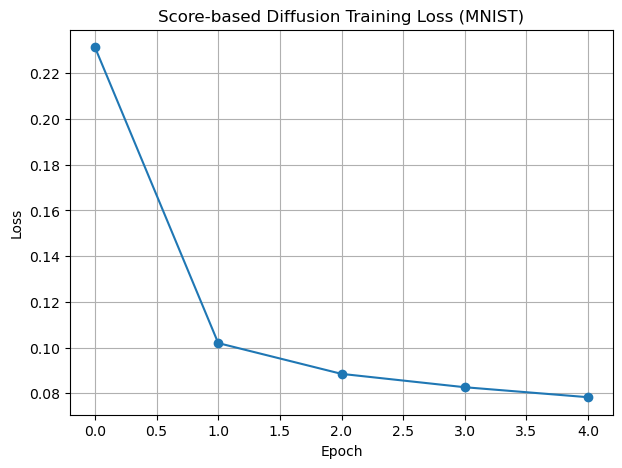

In [28]:
# ======================
# CONFIG
# ======================
class Config:
    lr = 2e-4
    epochs = 5
    eps = 1e-5   # your config.eps
    device = device

config = Config()

sde = VESDE(sigma_min=0.01, sigma_max=50, N=1000)

model = UNetConditional().to(config.device)
optimizer = optim.Adam(model.parameters(), lr=config.lr)

# ======================
# TRAINING LOOP
# ======================
train_losses = []


for epoch in range(config.epochs):
    epoch_losses = []
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.epochs}")

    for batch, labels in pbar:
        batch = batch.to(config.device)
        labels = labels.to(config.device)

        loss = train_step(config, batch, labels, model, sde, optimizer, train=True)
        epoch_losses.append(loss.item())

        pbar.set_postfix(loss=loss.item())

    mean_epoch_loss = sum(epoch_losses) / len(epoch_losses)
    train_losses.append(mean_epoch_loss)

    print(f"Epoch {epoch+1}: loss = {mean_epoch_loss:.6f}")
# ======================
# PLOT TRAINING CURVE
# ======================
plt.figure(figsize=(7,5))
plt.plot(train_losses, marker='o')
plt.title("Score-based Diffusion Training Loss (MNIST)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [29]:
class ConditionalSampler:
  def __init__(self, sde, score_fn):
    super().__init__()
    self.sde = sde
    self.score_fn = score_fn

  def update_fn(self, x, t, labels):
    dt = -1. / self.sde.N
    z = torch.randn_like(x)
    drift, diffusion = self.sde.reverse_sde(x, t, self.score_fn, labels = labels)
    x_mean = x + drift * dt
    x = x_mean + diffusion[:, None, None, None] * np.sqrt(-dt) * z
    return x, x_mean


def sample(sde, model, labels = None, num_samples = 1000, eps=1e-5, device = torch.device("cuda" if torch.cuda.is_available() else "cpu")):
    model.eval()
    score_fn = get_score_fn(sde, model)
    sampler = ConditionalSampler(sde = sde, score_fn = score_fn)
    shape = [num_samples, 1, 28, 28] # the shape has been hardcoded!
    x = sde.prior_sampling(shape).to(device)
    timesteps = torch.linspace(sde.T, eps, sde.N, device=device)
    with torch.no_grad():
      for i in tqdm(range(sde.N)):
          t = torch.ones(shape[0], device=device) * timesteps[i]
          x, x_mean = sampler.update_fn(x, t, labels)

    return x_mean


Now let's generate samples

In [30]:
conditioning = 1
num_samples = 20
labels = torch.ones(num_samples).to(device).long()*conditioning
samples = sample(sde, model, labels = labels, eps = config.eps, num_samples = num_samples)

  0%|          | 0/1000 [00:00<?, ?it/s]

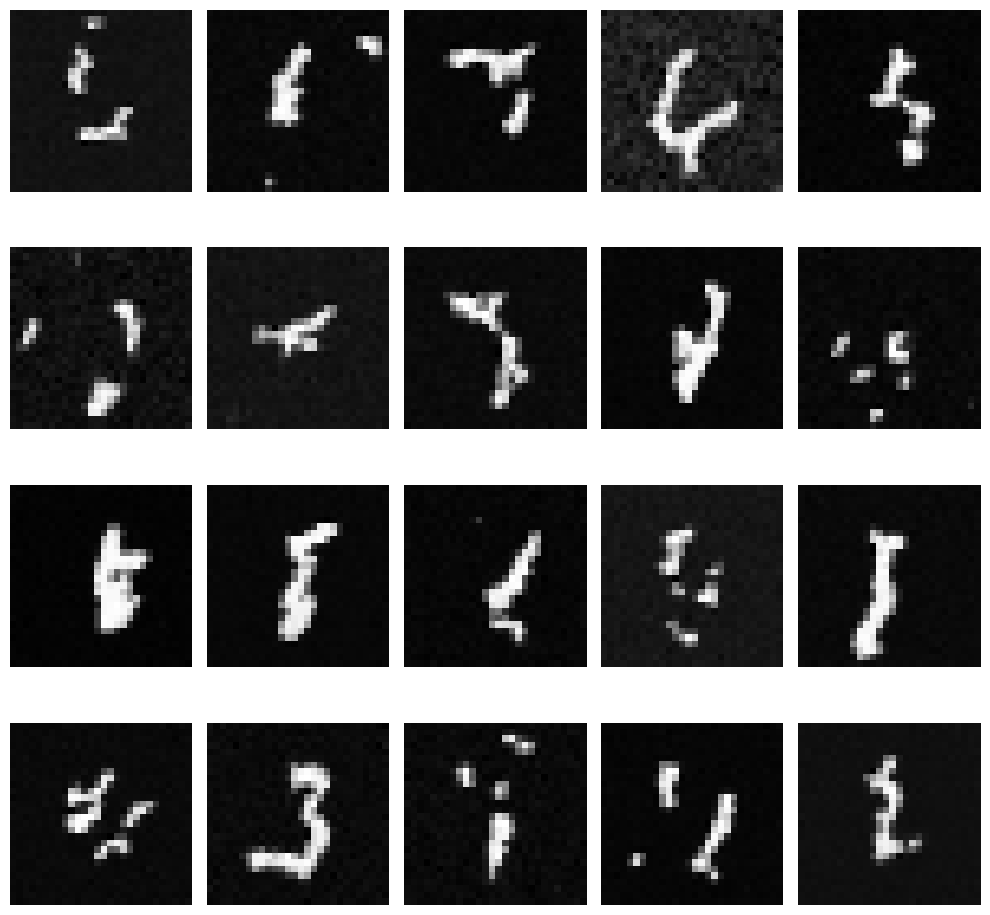

In [31]:
samples = samples.detach().cpu()   # ensure on CPU, no grad

fig, axes = plt.subplots(4, 5, figsize=(10, 10))

for i, ax in enumerate(axes.flatten()):
    img = samples[i, 0]            # [28, 28]
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()